In [ ]:
import pandas as pd
import numpy as np
import gc
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/jan-2025.csv'
buy_codes = [1, 2, 3, 5]
sell_codes = [4, 8, 10, 11]
cols = ['SUB_ACC', 'ISIN', 'TR_TYPE(*)', 'QUANTITY', 'VALUE (in Rs)', 'TR_DATE']
min_trades = 20
min_pos = 5

In [ ]:
df = pd.read_csv(file_path, usecols=cols)

In [ ]:
df = df[df['TR_TYPE(*)'].isin(buy_codes + sell_codes)].copy()
df = df.dropna(subset=['SUB_ACC'])
df = df[df['SUB_ACC'].str.strip() != '']

df['SIDE'] = 'SELL'
df.loc[df['TR_TYPE(*)'].isin(buy_codes), 'SIDE'] = 'BUY'

sell_date = (df[df['SIDE']=='SELL']
             .groupby(['SUB_ACC','ISIN'])['TR_DATE'].max()
             .reset_index()
             .rename(columns={'TR_DATE':'CLOSE_DATE'}))

buy_pos = df[df['SIDE']=='BUY'].groupby(['SUB_ACC','ISIN'])[['VALUE (in Rs)','QUANTITY']].sum()
buy_pos.columns = ['BUY_VAL', 'BUY_QTY']
buy_pos = buy_pos.reset_index()

sell_pos = df[df['SIDE']=='SELL'].groupby(['SUB_ACC','ISIN'])[['VALUE (in Rs)','QUANTITY']].sum()
sell_pos.columns = ['SELL_VAL', 'SELL_QTY']
sell_pos = sell_pos.reset_index()

pos = pd.merge(buy_pos, sell_pos, on=['SUB_ACC','ISIN'])
pos = pos[(pos['BUY_QTY']>0) & (pos['SELL_QTY']>0)].copy()
pos['AVG_BUY'] = pos['BUY_VAL'] / pos['BUY_QTY']
pos['AVG_SELL'] = pos['SELL_VAL'] / pos['SELL_QTY']
pos['WIN'] = (pos['AVG_SELL'] > pos['AVG_BUY']).astype(int)

pos = pd.merge(pos, sell_date, on=['SUB_ACC','ISIN'], how='left')

trade_count = df.groupby('SUB_ACC').size().reset_index(name='TRADE_COUNT')
valid_users = trade_count[trade_count['TRADE_COUNT'] >= min_trades]['SUB_ACC']
pos = pos[pos['SUB_ACC'].isin(valid_users)].copy()

pos.head()

,SUB_ACC,ISIN,BUY_VAL,BUY_QTY,SELL_VAL,SELL_QTY,AVG_BUY,AVG_SELL,WIN,CLOSE_DATE
0,S1000238085476,INE00H001014,3.787235e+07,87441.0,3.656418e+07,87441.0,433.118900,418.158300,0,2025-01-29
1,S1000238085476,INE758T01015,7.782691e+07,359683.0,1.327296e+08,590039.0,216.376400,224.950574,1,2025-01-29
2,S1001458825855,INE010J01012,1.094015e+08,102274.0,3.139821e+08,353474.0,1069.690385,888.274943,0,2025-01-30
3,S1001811484187,INE003A01024,3.035711e+07,5000.0,1.194715e+08,20500.0,6071.422200,5827.877000,0,2025-01-14
4,S1001811484187,INE009A01021,1.528825e+08,79050.0,1.978173e+08,106100.0,1933.997886,1864.442171,0,2025-01-28


In [ ]:
pos = pos.sort_values(['SUB_ACC', 'CLOSE_DATE'])
pos['POSITION_RANK'] = pos.groupby('SUB_ACC').cumcount() + 1

pos_counts = pos.groupby('SUB_ACC')['POSITION_RANK'].max()
valid = pos_counts[pos_counts >= min_pos].index
pos = pos[pos['SUB_ACC'].isin(valid)].copy()

pos[['SUB_ACC','ISIN','CLOSE_DATE','WIN','POSITION_RANK']].head(10)

,SUB_ACC,ISIN,CLOSE_DATE,WIN,POSITION_RANK
5,S1001811484187,INE040A01034,2025-01-03,1,1
9,S1001811484187,INE280A01028,2025-01-03,0,2
3,S1001811484187,INE003A01024,2025-01-14,0,3
11,S1001811484187,INE494B01023,2025-01-14,0,4
8,S1001811484187,INE195A01028,2025-01-21,1,5
12,S1001811484187,INE758T01015,2025-01-21,0,6
7,S1001811484187,INE101A01026,2025-01-22,0,7
14,S1001811484187,INE918Z01012,2025-01-22,1,8
10,S1001811484187,INE467B01029,2025-01-23,0,9
4,S1001811484187,INE009A01021,2025-01-28,0,10


In [ ]:
pos['CUM_WINS'] = pos.groupby('SUB_ACC')['WIN'].cumsum()
pos['CUM_WR'] = pos['CUM_WINS'] / pos['POSITION_RANK']

learning_curve = (pos.groupby('POSITION_RANK')['CUM_WR']
                  .agg(MEAN_WR='mean', MEDIAN_WR='median', N_USERS='count')
                  .reset_index())

learning_curve.head()

,POSITION_RANK,MEAN_WR,MEDIAN_WR,N_USERS
0,1,0.551948,1.000000,308
1,2,0.550325,0.500000,308
2,3,0.522727,0.666667,308
3,4,0.505682,0.500000,308
4,5,0.489610,0.400000,308


In [ ]:
lc = learning_curve.astype('float32')

d = {}
for metric in ['MEAN_WR', 'MEDIAN_WR']:
    stat, pval = spearmanr(lc[metric], lc['POSITION_RANK'], alternative='greater')
    d[metric] = {'spearman_r': round(stat, 4), 'pvalue': pval, 'result': 'significant' if pval < 0.05 else 'insignificant'}
    print(metric, '-> r:', round(stat, 4), ' p:', pval, '->', d[metric]['result'])

MEAN_WR -> r: 0.8147  p: 0.0 -> significant
MEDIAN_WR -> r: 0.6153  p: 1.3447418386349664e-149 -> significant


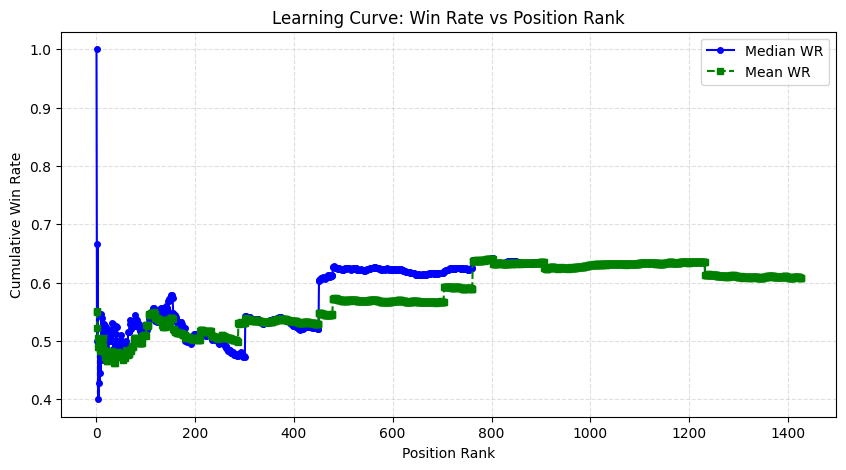

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(learning_curve['POSITION_RANK'], learning_curve['MEDIAN_WR'], 'b-o', markersize=4, label='Median WR')
ax.plot(learning_curve['POSITION_RANK'], learning_curve['MEAN_WR'], 'g--s', markersize=4, label='Mean WR')
ax.set_xlabel('Position Rank')
ax.set_ylabel('Cumulative Win Rate')
ax.set_title('Learning Curve: Win Rate vs Position Rank')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()